In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# 4_Model_Comparison.ipynb
# Purpose: Compare Tabular (Baseline + PCA) vs CNN (Image) models


# --- 1. Imports and Paths ---
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set base paths
# Ensure this path correctly points to the folder containing 'data' in your Google Drive
BASE_DIR = '/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data'
results_dir = os.path.join(BASE_DIR, 'results')
plots_dir = os.path.join(results_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)

print("Paths set up successfully")

Paths set up successfully


In [ ]:
# Load results from previous notebooks
tabular_path = os.path.join(results_dir, 'tabular_summary.csv')
cnn_path = os.path.join(results_dir, 'cnn_summary.csv')

tabular_df = pd.read_csv(tabular_path)
cnn_df = pd.read_csv(cnn_path)

# Combine into one DataFrame
comparison_df = pd.concat([tabular_df, cnn_df], ignore_index=True)
display(comparison_df)


,Model,Accuracy,F1-Score (macro),ROC AUC (macro),Precision (macro),Recall (macro)
0,Baseline (Raw Data),0.822500,0.822589,0.960427,NaN,NaN
1,PCA-Reduced Data,0.793923,0.793537,0.948581,NaN,NaN
2,CNN (Image Data),0.743692,0.742997,NaN,0.743468,0.743118


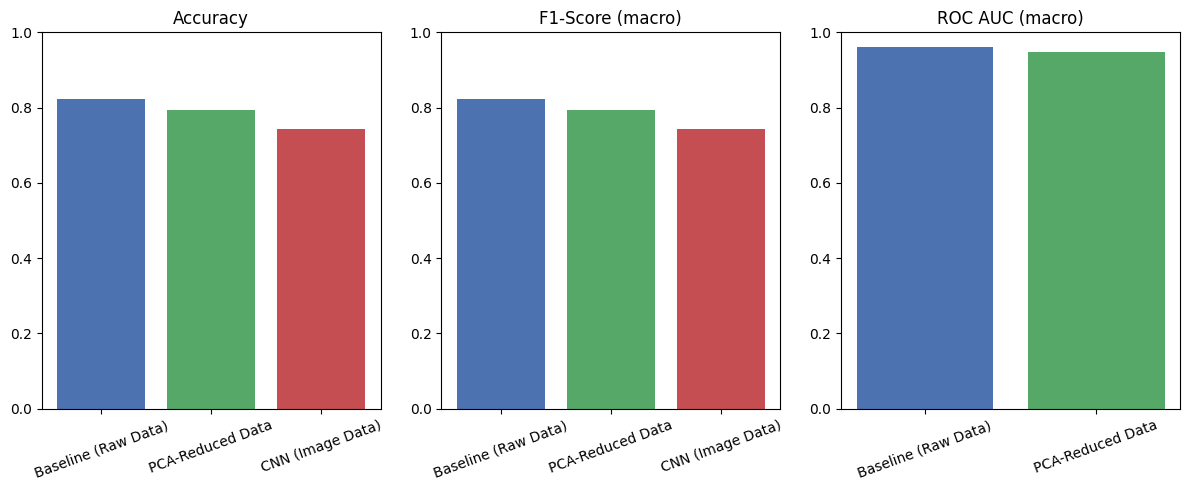

✅ Saved model comparison plot to /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results/plots/model_comparison.png


In [ ]:
# Plot Accuracy, F1, ROC-AUC side by side
metrics = ['Accuracy', 'F1-Score (macro)', 'ROC AUC (macro)']

plt.figure(figsize=(12,5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    plt.bar(comparison_df['Model'], comparison_df[metric], color=['#4C72B0', '#55A868', '#C44E52'])
    plt.title(metric)
    plt.xticks(rotation=20)
    plt.ylim(0, 1)
plt.tight_layout()

# Save plot
plt.savefig(os.path.join(plots_dir, 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved model comparison plot to {os.path.join(plots_dir, 'model_comparison.png')}")


In [ ]:
ranked_df = comparison_df.copy()
ranked_df['Rank (by Accuracy)'] = ranked_df['Accuracy'].rank(ascending=False)
ranked_df['Rank (by F1)'] = ranked_df['F1-Score (macro)'].rank(ascending=False)
ranked_df['Rank (by ROC AUC)'] = ranked_df['ROC AUC (macro)'].rank(ascending=False)
display(ranked_df)


,Model,Accuracy,F1-Score (macro),ROC AUC (macro),Precision (macro),Recall (macro),Rank (by Accuracy),Rank (by F1),Rank (by ROC AUC)
0,Baseline (Raw Data),0.822500,0.822589,0.960427,NaN,NaN,1.0,1.0,1.0
1,PCA-Reduced Data,0.793923,0.793537,0.948581,NaN,NaN,2.0,2.0,2.0
2,CNN (Image Data),0.743692,0.742997,NaN,0.743468,0.743118,3.0,3.0,NaN
